## Import libraries

In [16]:
import os
import sys

sys.path.insert(0, os.path.abspath('..'))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import load_metabric_data
from src.volcano_plot import compute_mutation_volcano

## Load Data

In [6]:
# Load & Filter
df, _ = load_metabric_data()
df_LumA = df[df['pam50_+_claudin-low_subtype'] == 'LumA'].copy()

Fetching METABRIC dataset from Kaggle...

Original dataset was loaded, shape: (1904, 693)
Original dataset was preprocessed, given a new shape: (679, 684)


In [7]:
df_LumA.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
10,36,85.49,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
13,46,83.02,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
23,68,51.01,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
29,97,78.19,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


## Volcano Plot Analysis

In [8]:
# Define Target (Mortality)
df_LumA['target_mortality'] = df_LumA['death_from_cancer'].apply(
    lambda x: 1 if str(x).strip().lower() == 'died of disease' else 0
    )
print(f"Target distribution:\n{df_LumA['target_mortality'].value_counts()}")

Target distribution:
target_mortality
0    533
1    146
Name: count, dtype: int64


In [9]:
# Clean mutations
mutation_cols = [col for col in df_LumA.columns if col.endswith('_mut')]
for col in mutation_cols:
    df_LumA[col] = np.where(df_LumA[col].astype(str).isin(['0']), 0, 1)

In [10]:
# Compute Statistics
volcano_data = compute_mutation_volcano(df_LumA, mutation_cols, "target_mortality", min_mutation_count=5)

In [ ]:
# Calculate Impact Scores and identify top candidates
volcano_data['Impact_Score'] = np.abs(volcano_data['Log2_OR']) * volcano_data['Neg_Log10_FDR']

# Select the top 7 candidate mutations
top_candidates = volcano_data.nlargest(7, 'Impact_Score') 

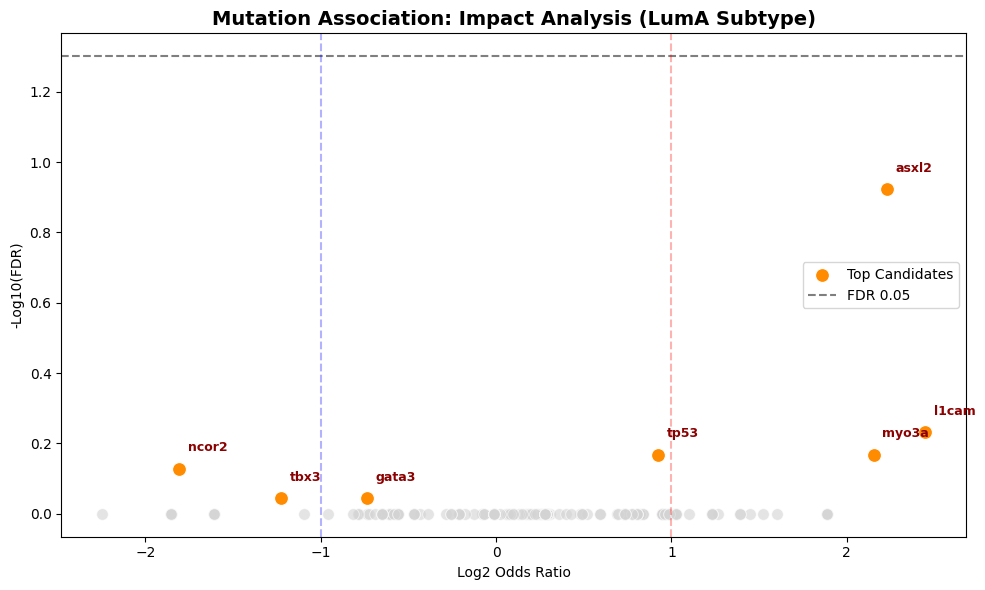

In [ ]:
# Plotting Phase
plt.figure(figsize=(10, 6))

# Plot all points in lightgrey
sns.scatterplot(data=volcano_data, x="Log2_OR", y="Neg_Log10_FDR", color="lightgrey", s=70, alpha=0.6)

# Plot top candidates in darkorange
sns.scatterplot(data=top_candidates, x="Log2_OR", y="Neg_Log10_FDR", color="darkorange", s=100, label="Top Candidates")

# Plot thresholds
plt.axhline(y=-np.log10(0.05), color="black", linestyle="--", alpha=0.5, label="FDR 0.05")
plt.axvline(x=1.0, color="red", linestyle="--", alpha=0.3)
plt.axvline(x=-1.0, color="blue", linestyle="--", alpha=0.3)

# Annotate top candidates
for _, row in top_candidates.iterrows():
    plt.text(
        row["Log2_OR"] + 0.05,
        row["Neg_Log10_FDR"] + 0.05,
        row["Mutation"].replace("_mut", ""), 
        fontsize=9,
        fontweight="bold",
        color="darkred"
    )

plt.title("Mutation Association: Impact Analysis (LumA Subtype)", fontsize=14, fontweight="bold")
plt.xlabel("Log2 Odds Ratio")
plt.ylabel("-Log10(FDR)")
plt.legend()
plt.tight_layout()
plt.show()